# Full Scale Optimization — Maximizing Investor Utility

Full Scale Optimization (FSO) drops the mean-variance assumption of MPT entirely.
Instead of optimizing on expected return and variance, FSO maximizes a utility
function across the **full empirical return distribution** — every actual monthly
return in the lookback window.

This matters because real investors are not mean-variance agents. They experience
losses more painfully than equivalent gains feel rewarding — a property called
loss aversion. FSO captures this by using a utility function that penalizes
downside outcomes more heavily than it rewards upside outcomes.

**Utility function**: Power utility / CRRA (Constant Relative Risk Aversion)

    U(r) = (1 + r)^(1 - γ) / (1 - γ)

Where γ (gamma) is the risk aversion coefficient. Higher gamma = more loss averse.

**Risk aversion parameter**: γ = 3.0 — moderate investor, consistent with
Mehra & Prescott (1985) empirical estimates of typical investor risk aversion.

FSO is the only model in this research that explicitly accounts for the shape
of the return distribution — skewness, fat tails, and extreme loss events.

Assets: `BND, GLD, TIP, TLT, VEU, VGT`

In [1]:
# ── Cell 1: Imports & Config ──────────────────────────────────────────────────
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.optimize as sco

warnings.filterwarnings("ignore")

with open("../../markets.json") as f:
    config = json.load(f)

market_name        = list(config["markets"].keys())[0]
data_folder        = Path("../../data")
initial_investment = config["initial_investment"]


In [2]:
# ── Key parameters ─────────────────────────────────────────────────────────────
LOOKBACK            = 36   # months of past returns used in rolling optimization
REBALANCE_THRESHOLD = 0.05 # only rebalance if any weight drifts more than 5%
VOL_TARGET          = 0.10  # annualised volatility target (matches Markowitz constraint)

# ── Risk aversion coefficient (gamma) ────────────────────────────────────────
# Source: Mehra & Prescott (1985). The equity premium: A puzzle.
# Journal of Monetary Economics, 15(2), 145-161.
# Empirical estimates place reasonable investor risk aversion between 1 and 10.
# Gamma = 3.0 represents a moderate investor — the standard academic default.
# Higher gamma = more loss averse, more conservative portfolio.
RISK_AVERSION_GAMMA = 3.0

# ── Crisis periods for chart shading ─────────────────────────────────────────
CRISES = [
    ("2008-09", "2009-06", "GFC"),
    ("2020-02", "2020-04", "COVID"),
    ("2022-01", "2022-12", "Rate Hikes"),
]

# ── Color palette ─────────────────────────────────────────────────────────────
PALETTE = {
    "FSO (γ=3.0)" : "#E53E3E",
    "Equal Weight": "#028090",
    "Min Variance": "#6B46C1",
}

plt.rcParams.update({
    "figure.facecolor" : "#F4F7FB",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.4,
    "grid.color"       : "#CBD5E0",
    "font.family"      : "sans-serif",
})

print(f"Market           : {market_name}")
print(f"Rolling window   : {LOOKBACK} months")
print(f"Risk aversion γ  : {RISK_AVERSION_GAMMA}")
print(f"Rebal threshold  : {REBALANCE_THRESHOLD*100:.0f}%")

Market           : primary_total_market
Rolling window   : 36 months
Risk aversion γ  : 3.0
Rebal threshold  : 5%


In [3]:
returns = pd.read_csv(
    data_folder / f"{market_name}_returns_monthly.csv",
    index_col=0, parse_dates=True
)
returns = returns.dropna()

assets     = list(returns.columns)
num_assets = len(assets)

print(f"Period : {returns.index[0].date()} -> {returns.index[-1].date()}")
print(f"Assets : {assets}")
print(f"Months : {len(returns)}")

Period : 2007-05-01 -> 2025-12-01
Assets : ['BND', 'GLD', 'TIP', 'TLT', 'VEU', 'VGT']
Months : 224


In [4]:
risk_free_file = data_folder / "risk_free_monthly.csv"

if risk_free_file.exists():
    risk_free_data        = pd.read_csv(risk_free_file, index_col=0, parse_dates=True)
    risk_free_data        = risk_free_data.reindex(returns.index, method="ffill")
    annual_rf_series      = risk_free_data["rf_annual"]
    monthly_rf_series     = risk_free_data["rf_monthly"]
    avg_annual_risk_free  = annual_rf_series.mean()
    avg_monthly_risk_free = monthly_rf_series.mean()
    print(f"Rolling RF loaded  : {len(risk_free_data)} months")
    print(f"  Range  : {annual_rf_series.min()*100:.2f}% - {annual_rf_series.max()*100:.2f}%")
    print(f"  Average: {avg_annual_risk_free*100:.3f}% annual")
else:
    print("WARNING: risk_free_monthly.csv not found. Run main.ipynb first.")
    avg_annual_risk_free  = 0.0162   # TB3MS historical mean 2007-2025
    avg_monthly_risk_free = (1 + avg_annual_risk_free) ** (1/12) - 1
    annual_rf_series      = pd.Series(avg_annual_risk_free,  index=returns.index)
    monthly_rf_series     = pd.Series(avg_monthly_risk_free, index=returns.index)

Rolling RF loaded  : 224 months
  Range  : 0.01% - 5.34%
  Average: 1.415% annual


In [5]:
# FSO Core Function ─────────────────────────────────────────────────
# Full Scale Optimization maximizes expected utility across the full
# empirical return distribution — not just mean and variance.
#
# Utility function: Power utility / CRRA
#   U(r) = (1 + r)^(1 - gamma) / (1 - gamma)
#
# This function has diminishing marginal utility — each additional dollar
# of gain is worth less than the previous one. And losses hurt more than
# equivalent gains feel good. The higher gamma is, the more pronounced
# this asymmetry becomes.
#
# The optimizer finds weights that maximize the AVERAGE utility across
# all T historical return observations in the lookback window:
#   maximize: (1/T) * sum[ U(portfolio_return_t) ] for t = 1..T
#
# Unlike MPT which summarizes the distribution into just mean and variance,
# FSO uses every single observation — capturing skewness and fat tails.

def compute_fso_weights(return_window, risk_aversion_gamma, num_assets):
    """
    Compute Full Scale Optimization portfolio weights.

    Parameters
    ----------
    return_window       : DataFrame of historical monthly returns (T x N)
    risk_aversion_gamma : CRRA risk aversion coefficient
    num_assets          : number of assets

    Returns
    -------
    optimal_weights     : portfolio weights that maximize expected utility
    """

    return_array = return_window.values  # shape: (T, N)

    def negative_expected_utility(weights):
        # Compute portfolio return for each historical period
        portfolio_returns = return_array @ weights  # shape: (T,)

        # Apply CRRA utility: U(r) = (1 + r)^(1 - gamma) / (1 - gamma)
        # If any (1 + r) <= 0 (total loss), utility is undefined — penalize heavily
        gross_returns = 1 + portfolio_returns
        if np.any(gross_returns <= 0):
            return 1e10

        if risk_aversion_gamma == 1.0:
            # Special case: log utility (limit as gamma -> 1)
            utility_values = np.log(gross_returns)
        else:
            utility_values = (
                gross_returns ** (1 - risk_aversion_gamma)
                / (1 - risk_aversion_gamma)
            )

        # Maximize average utility = minimize negative average utility
        return -np.mean(utility_values)

    cov_annual            = return_window.cov().values * 12  # annualised for vol constraint
    equal_initial_weights = np.ones(num_assets) / num_assets
    weight_bounds         = [(0.0, 1.0)] * num_assets

    constraints = [{"type": "eq", "fun": lambda weights: np.sum(weights) - 1}]
    if vol_target is not None:
        constraints.append({
            "type": "eq",
            "fun": lambda w, ca=cov_annual: np.sqrt(w @ ca @ w) - vol_target
        })

    optimization_result = sco.minimize(
        negative_expected_utility,
        equal_initial_weights,
        method      = "SLSQP",
        bounds      = weight_bounds,
        constraints = constraints,
        options     = {"ftol": 1e-12, "maxiter": 1000}
    )

    if optimization_result.success:
        return optimization_result.x
    else:
        return equal_initial_weights


print("FSO core function defined.")
print(f"Utility function : CRRA with gamma = {RISK_AVERSION_GAMMA}")
print("Ready for rolling simulation.")

FSO core function defined.
Utility function : CRRA with gamma = 3.0
Ready for rolling simulation.


In [6]:
# Rolling Simulation 

# Every month:
#   1. Look back 36 months of actual return observations
#   2. Find weights that maximize average CRRA utility across those observations
#   3. Apply rebalancing threshold
#   4. Earn next month's return

# Key distinction from MPT and Black-Litterman:
# FSO does not compute expected returns or covariance matrices.
# It works directly on the raw return observations.
# This makes it sensitive to the actual distribution shape —
# crash months in the window will pull weights away from risky assets.

rolling_weight_history = []
rolling_return_history = []
rolling_date_history   = []
monthly_turnover       = []

current_weights = np.ones(num_assets) / num_assets

for month_index in range(LOOKBACK, len(returns)):
    # Use only the past 36 months — no future data
    return_window = returns.iloc[month_index - LOOKBACK : month_index]

    try:
        new_target_weights = compute_fso_weights(
            return_window       = return_window,
            risk_aversion_gamma = RISK_AVERSION_GAMMA,
            num_assets          = num_assets,
            vol_target          = VOL_TARGET
        )
    except Exception:
        new_target_weights = np.ones(num_assets) / num_assets

    # Only rebalance if drift exceeds threshold
    weight_drift = np.abs(current_weights - new_target_weights)
    if weight_drift.max() > REBALANCE_THRESHOLD:
        trade_volume    = weight_drift.sum()
        current_weights = new_target_weights
    else:
        trade_volume = 0.0

    monthly_turnover.append(trade_volume)

    # Earn next month's return
    next_month_return = current_weights @ returns.iloc[month_index].values
    rolling_return_history.append(next_month_return)
    rolling_date_history.append(returns.index[month_index])
    rolling_weight_history.append(current_weights.copy())

    # Let weights drift naturally
    ending_values   = current_weights * (1 + returns.iloc[month_index].values)
    current_weights = ending_values / ending_values.sum()


rolling_weights_df = pd.DataFrame(rolling_weight_history,
                                   index=rolling_date_history, columns=assets)
fso_returns        = pd.Series(rolling_return_history, index=rolling_date_history)
turnover_series    = pd.Series(monthly_turnover,       index=rolling_date_history)
comparison_period  = fso_returns.index

# Benchmark strategies aligned to same period
equal_weight_returns = (returns * (1 / num_assets)).sum(axis=1).loc[comparison_period]

# Min Variance as secondary benchmark — closest MPT analog to FSO
full_covariance      = returns.loc[comparison_period].cov().values * 12

def portfolio_variance(weights):
    return weights @ full_covariance @ weights

min_var_result  = sco.minimize(
    portfolio_variance,
    np.ones(num_assets) / num_assets,
    method      = "SLSQP",
    bounds      = [(0.0, 1.0)] * num_assets,
    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1},
    options     = {"ftol": 1e-12, "maxiter": 1000}
)
min_var_weights  = min_var_result.x
min_var_returns  = (returns * min_var_weights).sum(axis=1).loc[comparison_period]

all_strategies = {
    "FSO (γ=3.0)" : fso_returns,
    "Min Variance" : min_var_returns,
    "Equal Weight" : equal_weight_returns,
}

# ── Re-align RF scalars to comparison_period ──────────────────────────────────
# Single source of truth for Sharpe — matches fix in 03-07.
avg_annual_risk_free  = annual_rf_series.reindex(comparison_period, method="ffill").mean()
avg_monthly_risk_free = monthly_rf_series.reindex(comparison_period, method="ffill").mean()

print(f"Rolling simulation done  : {len(fso_returns)} months")
print(f"Months rebalanced        : {(turnover_series > 0).sum()} / {len(turnover_series)}")
print(f"Average monthly turnover : {turnover_series.mean()*100:.2f}%")
print(f"RF rate (comparison period): {avg_annual_risk_free*100:.3f}% annual  <- used for Sharpe")
print()
print("── Average FSO weights (diagnostic — should be diversified for gamma=3.0) ──")
avg_weights = rolling_weights_df.mean()
for asset, w in avg_weights.items():
    print(f"  {asset}: {w*100:.1f}%")

Rolling simulation done  : 188 months
Months rebalanced        : 8 / 188
Average monthly turnover : 0.56%
RF rate (comparison period): 1.414% annual  <- used for Sharpe

── Average FSO weights (diagnostic — should be diversified for gamma=3.0) ──
  BND: 16.1%
  GLD: 16.7%
  TIP: 16.2%
  TLT: 16.5%
  VEU: 16.2%
  VGT: 18.3%


In [7]:
# Performance Summary 

def compute_performance_stats(monthly_returns, strategy_label):
    annualized_return     = ((1 + monthly_returns).cumprod().iloc[-1] ** (12 / len(monthly_returns)) - 1) * 100  # geometric CAGR
    annualized_volatility = monthly_returns.std()  * np.sqrt(12) * 100
    sharpe_ratio          = (
        (monthly_returns.mean() - avg_monthly_risk_free) * 12
        / (monthly_returns.std() * np.sqrt(12))
    )
    cumulative_value = (1 + monthly_returns).cumprod()
    rolling_peak     = cumulative_value.cummax()
    dd_series        = (cumulative_value - rolling_peak) / rolling_peak  # renamed to avoid shadowing
    max_drawdown     = dd_series.min() * 100
    final_value      = initial_investment * cumulative_value.iloc[-1]   # matches 02_simulate reporting

    # ── Downside metrics — unique to FSO analysis ─────────────────────────────
    # FSO is specifically designed to protect the downside.
    # Sortino ratio uses only downside deviation (not total vol).
    # This is the most appropriate performance measure for FSO.
    # Sortino: downside deviation across ALL periods [Sortino & van der Meer, 1991]
    shortfalls_08         = np.minimum(monthly_returns - avg_monthly_risk_free, 0)
    downside_deviation    = np.sqrt((shortfalls_08**2).mean()) * np.sqrt(12) * 100
    sortino_ratio         = (
        (monthly_returns.mean() - avg_monthly_risk_free) * 12
        / (np.sqrt((shortfalls_08**2).mean()) * np.sqrt(12))
        if (shortfalls_08**2).mean() > 0 else np.nan
    )

    return pd.Series({
        "Ann. Return %"     : round(annualized_return,     2),
        "Ann. Vol %"        : round(annualized_volatility, 2),
        "Sharpe Ratio"      : round(sharpe_ratio,          3),
        "Sortino Ratio"     : round(sortino_ratio,         3),
        "Max Drawdown %"    : round(max_drawdown,          2),
        "Downside Dev %"    : round(downside_deviation,    2),
        "Final Value ($)"  : round(final_value,           2),
    }, name=strategy_label)


summary_table = pd.DataFrame([
    compute_performance_stats(monthly_returns, label)
    for label, monthly_returns in all_strategies.items()
])

print("── Performance Summary ──")
print(summary_table.to_string())
print()
print("Key metric: Sortino Ratio — FSO is designed to minimize downside deviation.")
print("If FSO's Sortino exceeds Min Variance, the utility function is doing its job.")

── Performance Summary ──
              Ann. Return %  Ann. Vol %  Sharpe Ratio  Sortino Ratio  Max Drawdown %  Downside Dev %  Final Value ($)
FSO (γ=3.0)            7.58        8.01         0.773          1.215          -21.42            5.10          3111.13
Min Variance           2.60        4.58         0.264          0.373          -15.63            3.24          1477.60
Equal Weight           7.46        8.09         0.750          1.180          -21.17            5.14          3047.98

Key metric: Sortino Ratio — FSO is designed to minimize downside deviation.
If FSO's Sortino exceeds Min Variance, the utility function is doing its job.


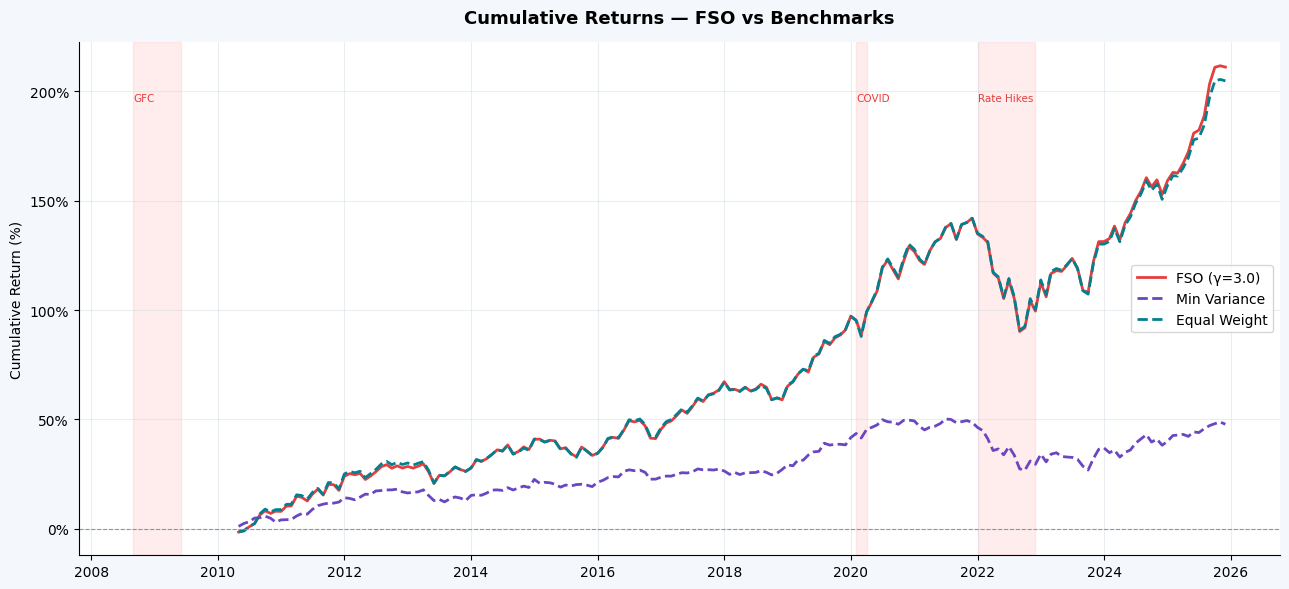

In [8]:
# Cumulative Returns 

fig, ax = plt.subplots(figsize=(13, 6))

for label, monthly_returns in all_strategies.items():
    cumulative_growth_pct = ((1 + monthly_returns).cumprod() - 1) * 100
    ax.plot(cumulative_growth_pct, label=label,
            color=PALETTE[label], linewidth=2,
            linestyle="--" if label != "FSO (γ=3.0)" else "-")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_max = ax.get_ylim()[1]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_max * 0.88,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Returns — FSO vs Benchmarks",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Cumulative Return (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

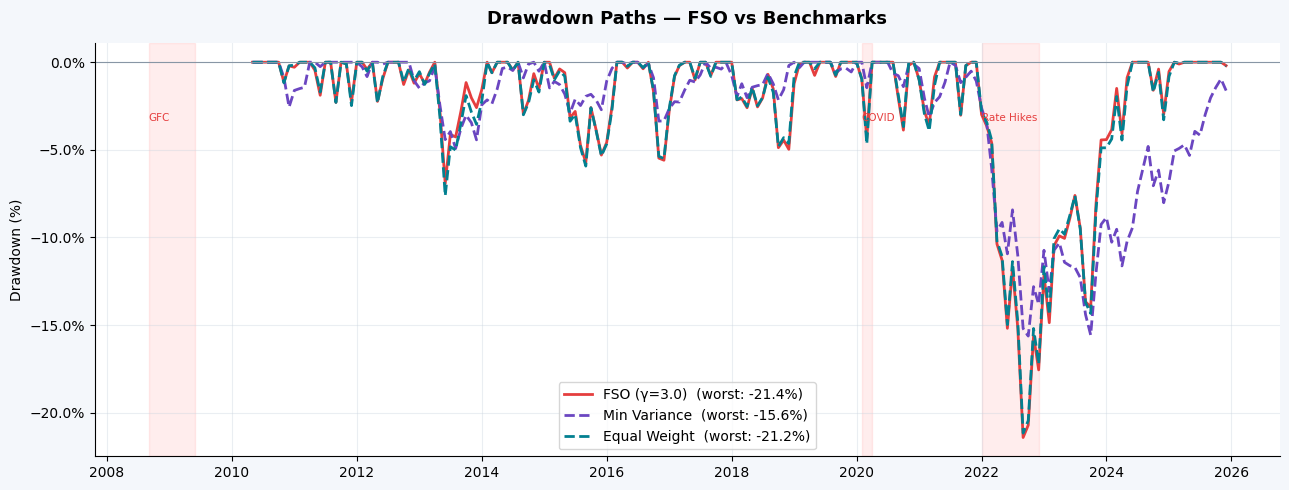

In [9]:
# Drawdown Paths 

# This is the most important chart for FSO.
# FSO is specifically designed to protect against deep drawdowns.
# If the utility function is working, FSO should show shallower drawdowns
# than Min Variance and Equal Weight during crisis periods.

fig, ax = plt.subplots(figsize=(13, 5))

for label, monthly_returns in all_strategies.items():
    cumulative_value = (1 + monthly_returns).cumprod()
    rolling_peak     = cumulative_value.cummax()
    drawdown_pct     = ((cumulative_value - rolling_peak) / rolling_peak) * 100
    ax.plot(drawdown_pct,
            label=f"{label}  (worst: {drawdown_pct.min():.1f}%)",
            color=PALETTE[label], linewidth=2,
            linestyle="--" if label != "FSO (γ=3.0)" else "-")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_min = ax.get_ylim()[0]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_min * 0.15,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8)
ax.set_title("Drawdown Paths — FSO vs Benchmarks",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

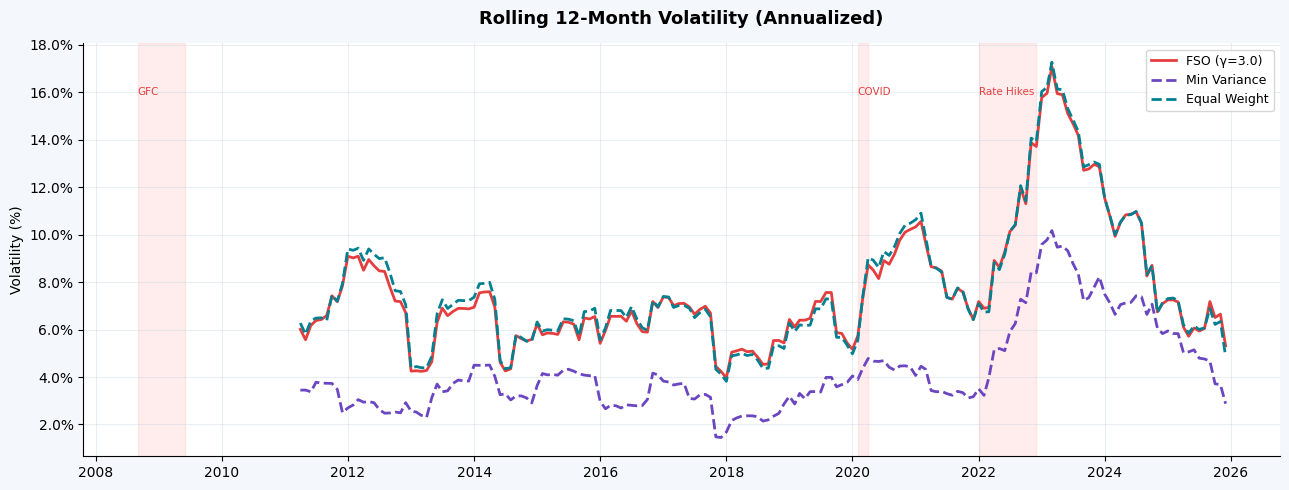

In [10]:
# Rolling 12-Month Volatility 

rolling_window_months = 12

fig, ax = plt.subplots(figsize=(13, 5))

for label, monthly_returns in all_strategies.items():
    rolling_vol = (
        monthly_returns.rolling(rolling_window_months).std() * np.sqrt(12) * 100
    )
    ax.plot(rolling_vol, label=label,
            color=PALETTE[label], linewidth=2,
            linestyle="--" if label != "FSO (γ=3.0)" else "-")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_max = ax.get_ylim()[1]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_max * 0.88,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.set_title(f"Rolling {rolling_window_months}-Month Volatility (Annualized)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Volatility (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [11]:
# Recovery Dynamics 

def months_to_recover(monthly_returns, crisis_start, crisis_end):
    cumulative_value  = (1 + monthly_returns).cumprod()
    pre_crisis_values = cumulative_value.loc[:crisis_start]
    if pre_crisis_values.empty:
        return None
    pre_crisis_peak   = pre_crisis_values.max()
    crisis_values     = cumulative_value.loc[crisis_start:crisis_end]
    if crisis_values.empty:
        return None
    trough_date       = crisis_values.idxmin()
    post_trough       = cumulative_value.loc[trough_date:]
    recovered_months  = post_trough[post_trough >= pre_crisis_peak]
    if recovered_months.empty:
        return None
    recovery_date     = recovered_months.index[0]
    months_elapsed    = len(cumulative_value.loc[trough_date:recovery_date]) - 1
    return months_elapsed


print("── Recovery Time (months from trough back to pre-crisis peak) ──\n")
print("Note: GFC shows 'Not recovered' because the 36-month rolling window")
print("means the simulation begins after the crisis onset. See Bookmark #5.\n")
header = f"{'Crisis':<16}" + "".join(f"{label:>22}" for label in all_strategies)
print(header)
print("-" * len(header))

for crisis_start, crisis_end, crisis_label in CRISES:
    row = f"{crisis_label:<16}"
    for label, monthly_returns in all_strategies.items():
        months = months_to_recover(monthly_returns, crisis_start, crisis_end)
        row += f"{'Not recovered':>22}" if months is None else f"{months} months".rjust(22)
    print(row)

── Recovery Time (months from trough back to pre-crisis peak) ──

Note: GFC shows 'Not recovered' because the 36-month rolling window
means the simulation begins after the crisis onset. See Bookmark #5.

Crisis                     FSO (γ=3.0)          Min Variance          Equal Weight
----------------------------------------------------------------------------------
GFC                      Not recovered         Not recovered         Not recovered
COVID                         1 months              1 months              1 months
Rate Hikes                   21 months         Not recovered             21 months


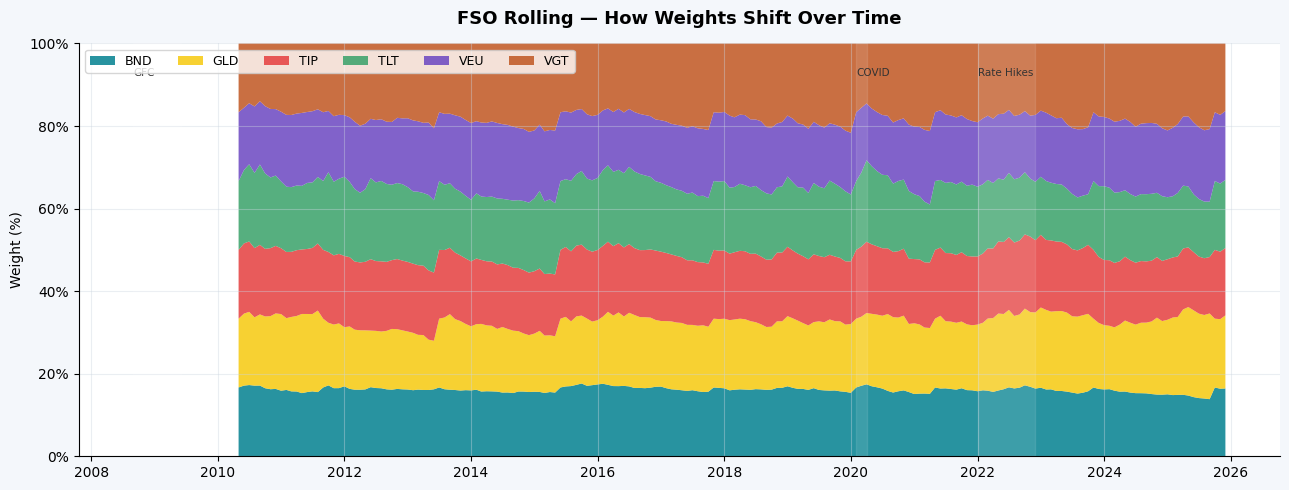

In [12]:
# Rolling Weight Evolution 

# FSO weights are driven by the utility function's response to bad months.
# When a crash month enters the 36-month window, FSO shifts away from
# the asset that crashed. When it rolls out 36 months later, FSO may
# shift back. This creates a systematic lag in the weight response.

asset_colors = ["#028090", "#F6C90E", "#E53E3E", "#38A169", "#6B46C1", "#C05621"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(
    rolling_weights_df.index,
    [rolling_weights_df[asset] * 100 for asset in assets],
    labels=assets, colors=asset_colors, alpha=0.85
)

for crisis_start, crisis_end, _ in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.10, color="white", zorder=2)
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), 92,
            crisis_label, fontsize=7.5, color="#333")

ax.set_title("FSO Rolling — How Weights Shift Over Time",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Weight (%)")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9, ncol=num_assets, loc="upper left")
plt.tight_layout()
plt.show()

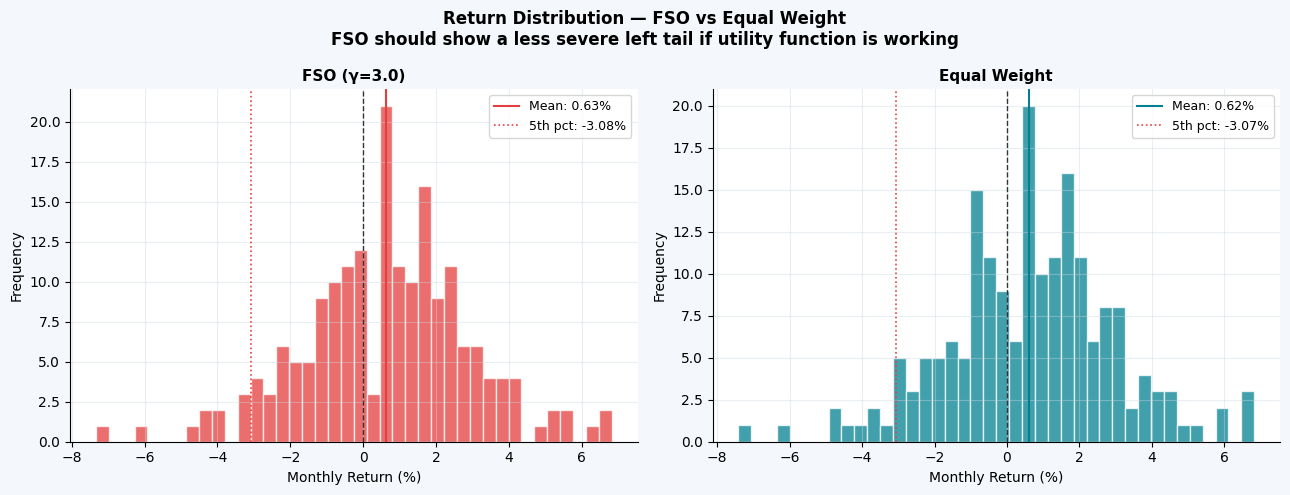

In [13]:
# Return Distribution — FSO vs Equal Weight 
# FSO is designed to shift the return distribution — specifically to reduce
# the frequency and severity of large negative returns (left tail).
# This chart makes that effect visible.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_index, (label, monthly_returns) in enumerate([
    ("FSO (γ=3.0)",  fso_returns),
    ("Equal Weight", equal_weight_returns)
]):
    ax = axes[ax_index]
    color = PALETTE[label]

    ax.hist(monthly_returns * 100, bins=40,
            color=color, alpha=0.75, edgecolor="white")
    ax.axvline(0, color="#333", linewidth=1.0, linestyle="--")
    ax.axvline(monthly_returns.mean() * 100,
               color=color, linewidth=1.5, linestyle="-",
               label=f"Mean: {monthly_returns.mean()*100:.2f}%")

    worst_5  = np.percentile(monthly_returns * 100, 5)
    ax.axvline(worst_5, color="#E53E3E", linewidth=1.2, linestyle=":",
               label=f"5th pct: {worst_5:.2f}%")

    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Monthly Return (%)")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

fig.suptitle(
    "Return Distribution — FSO vs Equal Weight\n"
    "FSO should show a less severe left tail if utility function is working",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

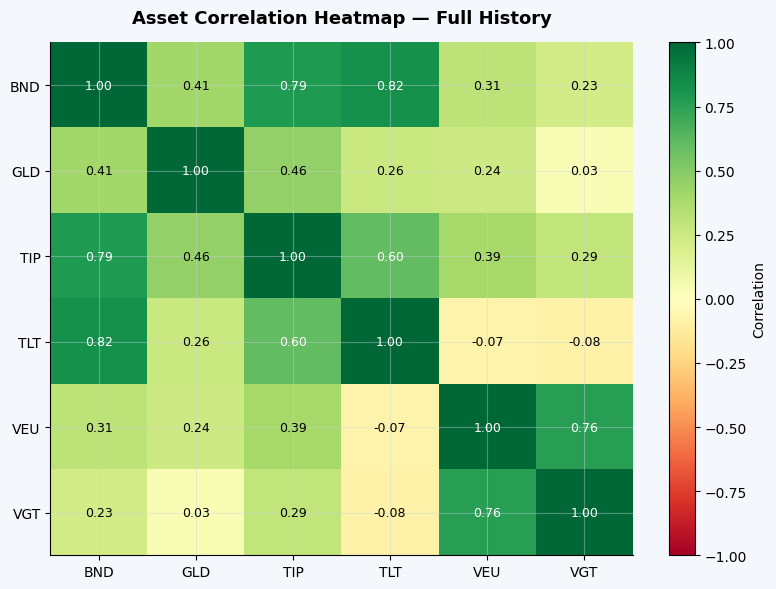

In [14]:
# Correlation Heatmap 

correlation_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
colormap = plt.cm.RdYlGn
heatmap  = ax.imshow(correlation_matrix, cmap=colormap, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(heatmap, ax=ax, label="Correlation")

ax.set_xticks(range(num_assets))
ax.set_yticks(range(num_assets))
ax.set_xticklabels(assets, fontsize=10)
ax.set_yticklabels(assets, fontsize=10)

for row_index in range(num_assets):
    for col_index in range(num_assets):
        correlation_value = correlation_matrix.iloc[row_index, col_index]
        text_color        = "white" if abs(correlation_value) > 0.6 else "black"
        ax.text(col_index, row_index,
                f"{correlation_value:.2f}",
                ha="center", va="center",
                fontsize=9, color=text_color)

ax.set_title("Asset Correlation Heatmap — Full History",
             fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()